In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_churn.csv')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (500, 9)

Columns:
 Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Data Types:
 CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object


Churn
0    447
1     53
Name: count, dtype: int64


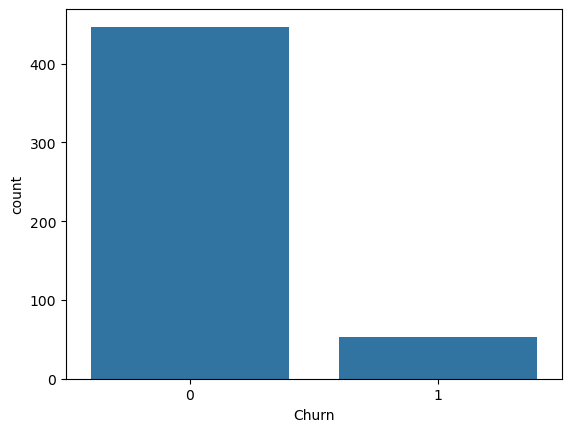

In [4]:
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.show()

In [5]:
print(df.isnull().sum())

df = df.fillna('Unknown')

print("Missing values handled")

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64
Missing values handled


In [6]:
# Convert all categorical columns to numeric
df = pd.get_dummies(df)

print("Encoding Done")
print(df.head())

Encoding Done
   Tenure  MonthlyCharges  TotalCharges  SeniorCitizen  Churn  \
0       6              64          1540              1      0   
1      21             113          1753              1      0   
2      27              31          1455              1      0   
3      53              29          7150              1      0   
4      16             185          1023              1      0   

   CustomerID_C00001  CustomerID_C00002  CustomerID_C00003  CustomerID_C00004  \
0               True              False              False              False   
1              False               True              False              False   
2              False              False               True              False   
3              False              False              False               True   
4              False              False              False              False   

   CustomerID_C00005  ...  CustomerID_C00499  CustomerID_C00500  \
0              False  ...              Fa

In [7]:
print(df.dtypes)
print("Shape after encoding:", df.shape)

Tenure                            int64
MonthlyCharges                    int64
TotalCharges                      int64
SeniorCitizen                     int64
Churn                             int64
                                  ...  
PaymentMethod_Bank Transfer        bool
PaymentMethod_Credit Card          bool
PaymentMethod_Electronic Check     bool
PaperlessBilling_No                bool
PaperlessBilling_Yes               bool
Length: 513, dtype: object
Shape after encoding: (500, 513)


In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max Scaling
minmax = MinMaxScaler()
df[['MonthlyCharges']] = minmax.fit_transform(df[['MonthlyCharges']])

# Standard Scaling
scaler = StandardScaler()
df[['Tenure']] = scaler.fit_transform(df[['Tenure']])

print("Scaling Done")

Scaling Done


In [9]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

# Apply carefully (won't delete all data)
df = df[(df['MonthlyCharges'] >= Q1 - 1.5*IQR) &
        (df['MonthlyCharges'] <= Q3 + 1.5*IQR)]

print("After outlier removal:", df.shape)

After outlier removal: (500, 513)


In [21]:
df['TotalCharges'] = df['MonthlyCharges'] * df['Tenure']
df['AvgCharges'] = df['TotalCharges'] / (df['Tenure'] + 1)
df['IsLongTerm'] = (df['Tenure'] > 0).astype(int)
df['ChargeRatio'] = df['MonthlyCharges'] / (df['Tenure'] + 1)
df['TenureGroup'] = pd.cut(df['Tenure'], bins=4, labels=[1,2,3,4])

print("Feature Engineering Done")

Feature Engineering Done


Generating Heatmap...
Numeric columns found: 8


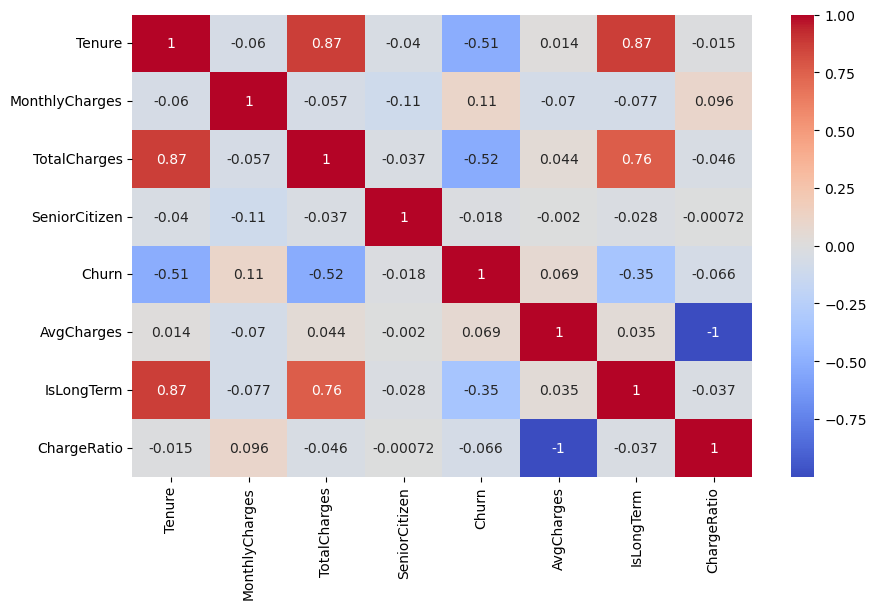

Heatmap displayed


In [33]:
import numpy as np

print("Generating Heatmap...")

# Clean data
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Numeric columns found:", len(numeric_df.columns))

if len(numeric_df.columns) > 0:
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.show()
    print("Heatmap displayed")
else:
    print("No numeric data to plot")

In [23]:
from sklearn.model_selection import train_test_split

# Ensure Churn exists
print("Columns:", df.columns)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split Done")

Columns: Index(['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn',
       'CustomerID_C00001', 'CustomerID_C00002', 'CustomerID_C00003',
       'CustomerID_C00004', 'CustomerID_C00005',
       ...
       'Contract_Two year', 'PaymentMethod_Bank Transfer',
       'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check',
       'PaperlessBilling_No', 'PaperlessBilling_Yes', 'AvgCharges',
       'IsLongTerm', 'ChargeRatio', 'TenureGroup'],
      dtype='object', length=517)
Split Done


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Trained")

Model Trained


In [25]:
y_pred = model.predict(X_test)

print("Prediction Done")

Prediction Done


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.94

Confusion Matrix:
 [[83  1]
 [ 5 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97        84
           1       0.92      0.69      0.79        16

    accuracy                           0.94       100
   macro avg       0.93      0.84      0.88       100
weighted avg       0.94      0.94      0.94       100



In [27]:
importance = model.feature_importances_

for i, col in enumerate(X.columns):
    print(col, ":", importance[i])

Tenure : 0.18929722541785954
MonthlyCharges : 0.04870298463633989
TotalCharges : 0.11367337586660682
SeniorCitizen : 0.011409708779310324
CustomerID_C00001 : 0.0
CustomerID_C00002 : 3.496234808501315e-05
CustomerID_C00003 : 0.0
CustomerID_C00004 : 4.617231507987525e-06
CustomerID_C00005 : 0.0006155871362171736
CustomerID_C00006 : 1.0596026065960838e-05
CustomerID_C00007 : 0.0
CustomerID_C00008 : 7.890238793132885e-07
CustomerID_C00009 : 8.087474120087313e-07
CustomerID_C00010 : 0.0
CustomerID_C00011 : 4.618928719387976e-06
CustomerID_C00012 : 0.0
CustomerID_C00013 : 2.0346126438914746e-05
CustomerID_C00014 : 0.007123633006708357
CustomerID_C00015 : 0.0
CustomerID_C00016 : 0.0
CustomerID_C00017 : 6.261072827105265e-06
CustomerID_C00018 : 7.932421336821702e-06
CustomerID_C00019 : 0.0
CustomerID_C00020 : 8.768183750839226e-06
CustomerID_C00021 : 0.0
CustomerID_C00022 : 3.216708355184728e-07
CustomerID_C00023 : 0.0
CustomerID_C00024 : 1.0394623082528392e-05
CustomerID_C00025 : 0.0
Customer

In [28]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print("Pipeline Accuracy:", accuracy_score(y_test, pipeline_pred))

Pipeline Accuracy: 0.94


In [29]:
print(df.head())
print("Final Shape:", df.shape)

     Tenure  MonthlyCharges  TotalCharges  SeniorCitizen  Churn  \
0 -1.478807        0.245810     -0.363506              1      0   
1 -0.752287        0.519553     -0.390853              1      0   
2 -0.461679        0.061453     -0.028371              1      0   
3  0.797622        0.050279      0.040104              1      0   
4 -0.994460        0.921788     -0.916681              1      0   

   CustomerID_C00001  CustomerID_C00002  CustomerID_C00003  CustomerID_C00004  \
0               True              False              False              False   
1              False               True              False              False   
2              False              False               True              False   
3              False              False              False               True   
4              False              False              False              False   

   CustomerID_C00005  ...  Contract_Two year  PaymentMethod_Bank Transfer  \
0              False  ...        